In [246]:
import pandas as pd
import bs4 as bs
import seaborn as sns
import matplotlib.pyplot as plt



In [247]:
with open("page1.html", "r", encoding="utf-8") as file:
    movies_data = file.read()

soup = bs.BeautifulSoup(movies_data, "html.parser")

table = soup.find("table")

rows = table.tbody.find_all("tr")

years = []
crips = []

for row in rows:
    year = row.find_all("td")[0].get_text()
    if year.isdigit() and int(year) < 2017:
        years.append(int(year))
        crips.append(row.find_all("td")[13].get_text())

cpi_table = pd.DataFrame({
    "year": years,
    "cpi": crips
})

cpi_table

,year,cpi
0,1913,9.9
1,1914,10.0
2,1915,10.1
3,1916,10.9
4,1917,12.8
...,...,...
99,2012,229.594
100,2013,232.957
101,2014,236.736
102,2015,237.017


In [248]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

In [249]:
movies_data = pd.read_csv("data_sets/Dataset1.csv")

In [250]:
movies_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   color                       5025 non-null   str    
 1   Director_Name               4872 non-null   str    
 2   num_Critic_for_reviews      4927 non-null   float64
 3   duration                    4959 non-null   float64
 4   director_Facebook_likes     4872 non-null   float64
 5   actor_3_Facebook_likes      4953 non-null   float64
 6   actor_2_name                4963 non-null   str    
 7   Actor_1_Facebook_likes      4968 non-null   float64
 8   gross                       4104 non-null   float64
 9   genres                      4974 non-null   str    
 10  actor_1_name                4968 non-null   str    
 11  movie_Title                 4974 non-null   str    
 12  num_voted_users             4974 non-null   float64
 13   cast_total_facebook_likes  4974 non-null   

In [251]:
movies_data.duplicated().sum()

np.int64(45)

In [252]:
movies_data.drop_duplicates()

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84;
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000;
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16;
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660;


In [253]:
movies_data.isna().sum()

color                          18
Director_Name                 171
num_Critic_for_reviews        116
duration                       84
director_Facebook_likes       171
actor_3_Facebook_likes         90
actor_2_name                   80
Actor_1_Facebook_likes         75
gross                         939
genres                         69
actor_1_name                   75
movie_Title                    69
num_voted_users                69
 cast_total_facebook_likes     69
actor_3_name                   90
facenumber_in_poster           82
plot_keywords                 216
movie_imdb_link                69
num_user_for_reviews           87
language                       82
country                        72
content_rating                366
budget                        549
title_year                    174
actor_2_facebook_likes         80
imdb_score                     69
aspect_ratio                  389
movie_facebook_likes;          69
dtype: int64

In [254]:
str_columns = movies_data.select_dtypes(include='string').columns
str_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_Title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating', 'movie_facebook_likes;'],
      dtype='str')

In [255]:
categorial_columns = str_columns.drop("movie_facebook_likes;")

movies_data.rename({"movie_facebook_likes;": "movie_facebook_likes"}, inplace = True, axis=1)
movies_data["movie_facebook_likes"] = movies_data["movie_facebook_likes"].str.replace(";", "")
movies_data["movie_facebook_likes"] = movies_data["movie_facebook_likes"].astype(float)

categorial_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_Title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating'],
      dtype='str')

In [256]:
for column in categorial_columns:
    movies_data[column] = movies_data[column].fillna(movies_data[column].mode()[0])

numeric_columns = movies_data.select_dtypes(include="number").columns
for column in numeric_columns:
    movies_data[column] = movies_data[column].fillna(movies_data[column].median())

In [257]:
movies_data.isna().sum()

color                         0
Director_Name                 0
num_Critic_for_reviews        0
duration                      0
director_Facebook_likes       0
actor_3_Facebook_likes        0
actor_2_name                  0
Actor_1_Facebook_likes        0
gross                         0
genres                        0
actor_1_name                  0
movie_Title                   0
num_voted_users               0
 cast_total_facebook_likes    0
actor_3_name                  0
facenumber_in_poster          0
plot_keywords                 0
movie_imdb_link               0
num_user_for_reviews          0
language                      0
country                       0
content_rating                0
budget                        0
title_year                    0
actor_2_facebook_likes        0
imdb_score                    0
aspect_ratio                  0
movie_facebook_likes          0
dtype: int64

In [258]:
real_domestic_gross = []
real_budget_values = []
cpi_2016 = float((cpi_table[cpi_table["year"] == 2016]["cpi"]).values[0])

for index, row in movies_data.iterrows():
    gross = row["gross"]
    budget = row["budget"]
    year = row["title_year"]
    cpi = float(cpi_table[ cpi_table["year"] == year ]["cpi"].values[0])

    real_gross = get_real_value(gross, cpi, cpi_2016)
    real_budget = get_real_value(budget, cpi, cpi_2016)
    real_domestic_gross.append(real_gross)
    real_budget_values.append(real_budget)

movies_data["real_domestic_gross"] = real_domestic_gross
movies_data["real_budget"] = real_budget_values
movies_data.drop(["gross", "budget"], axis=1, inplace=True)

In [259]:
movies_data.describe()

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,real_domestic_gross,real_budget
count,5043.000000,5043.000000,5043.000000,5043.000000,5043.00000,5.043000e+03,5043.000000,5043.000000,5043.000000,5043.000000,5043.000000,5043.000000,5043.000000,5043.000000,5.043000e+03,5.043000e+03
mean,139.869720,107.124132,669.456871,642.868531,6490.47214,8.315077e+04,9638.549177,1.366647,271.573468,2002.574658,1643.190561,6.441959,2.233119,7470.780984,6.805656e+07,4.890401e+07
std,120.535511,24.774814,2776.189759,1658.130651,14979.85268,1.378445e+05,18119.377709,2.001342,375.774914,12.225589,4025.851655,1.116440,1.338851,19308.507567,1.231890e+08,2.381263e+08
min,1.000000,7.000000,0.000000,0.000000,0.00000,5.000000e+00,0.000000,0.000000,1.000000,1916.000000,0.000000,1.600000,1.180000,0.000000,1.642384e+02,2.843561e+02
25%,51.000000,93.000000,8.000000,139.500000,625.00000,8.972500e+03,1442.000000,0.000000,67.000000,1999.000000,290.000000,5.800000,1.850000,0.000000,1.209229e+07,1.115199e+07
50%,110.000000,103.000000,49.000000,372.000000,989.00000,3.450400e+04,3097.500000,1.000000,157.000000,2005.000000,595.000000,6.600000,2.350000,165.500000,3.144961e+07,2.457829e+07
75%,192.000000,117.000000,188.000000,633.000000,11000.00000,9.444550e+04,13629.500000,2.000000,322.000000,2010.000000,912.000000,7.200000,2.350000,3000.000000,7.780360e+07,5.445345e+07
max,813.000000,511.000000,23000.000000,23000.000000,640000.00000,1.689764e+06,656730.000000,43.000000,5060.000000,2016.000000,137000.000000,9.500000,16.000000,349000.000000,3.430119e+09,1.454269e+10


array([[<Axes: title={'center': 'num_Critic_for_reviews'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'director_Facebook_likes'}>,
        <Axes: title={'center': 'actor_3_Facebook_likes'}>],
       [<Axes: title={'center': 'Actor_1_Facebook_likes'}>,
        <Axes: title={'center': 'num_voted_users'}>,
        <Axes: title={'center': ' cast_total_facebook_likes'}>,
        <Axes: title={'center': 'facenumber_in_poster'}>],
       [<Axes: title={'center': 'num_user_for_reviews'}>,
        <Axes: title={'center': 'title_year'}>,
        <Axes: title={'center': 'actor_2_facebook_likes'}>,
        <Axes: title={'center': 'imdb_score'}>],
       [<Axes: title={'center': 'aspect_ratio'}>,
        <Axes: title={'center': 'movie_facebook_likes'}>,
        <Axes: title={'center': 'real_domestic_gross'}>,
        <Axes: title={'center': 'real_budget'}>]], dtype=object)

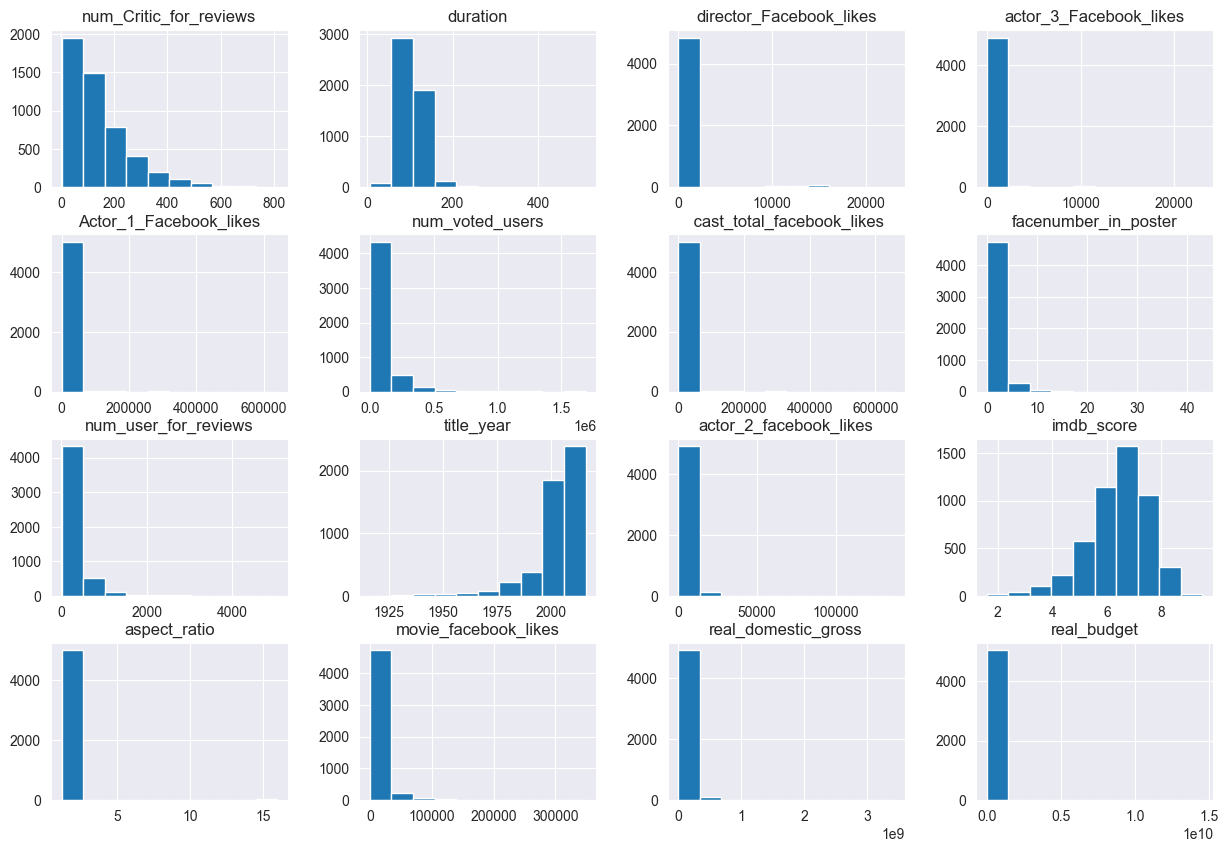

In [260]:
movies_data.hist(figsize=(15, 10))

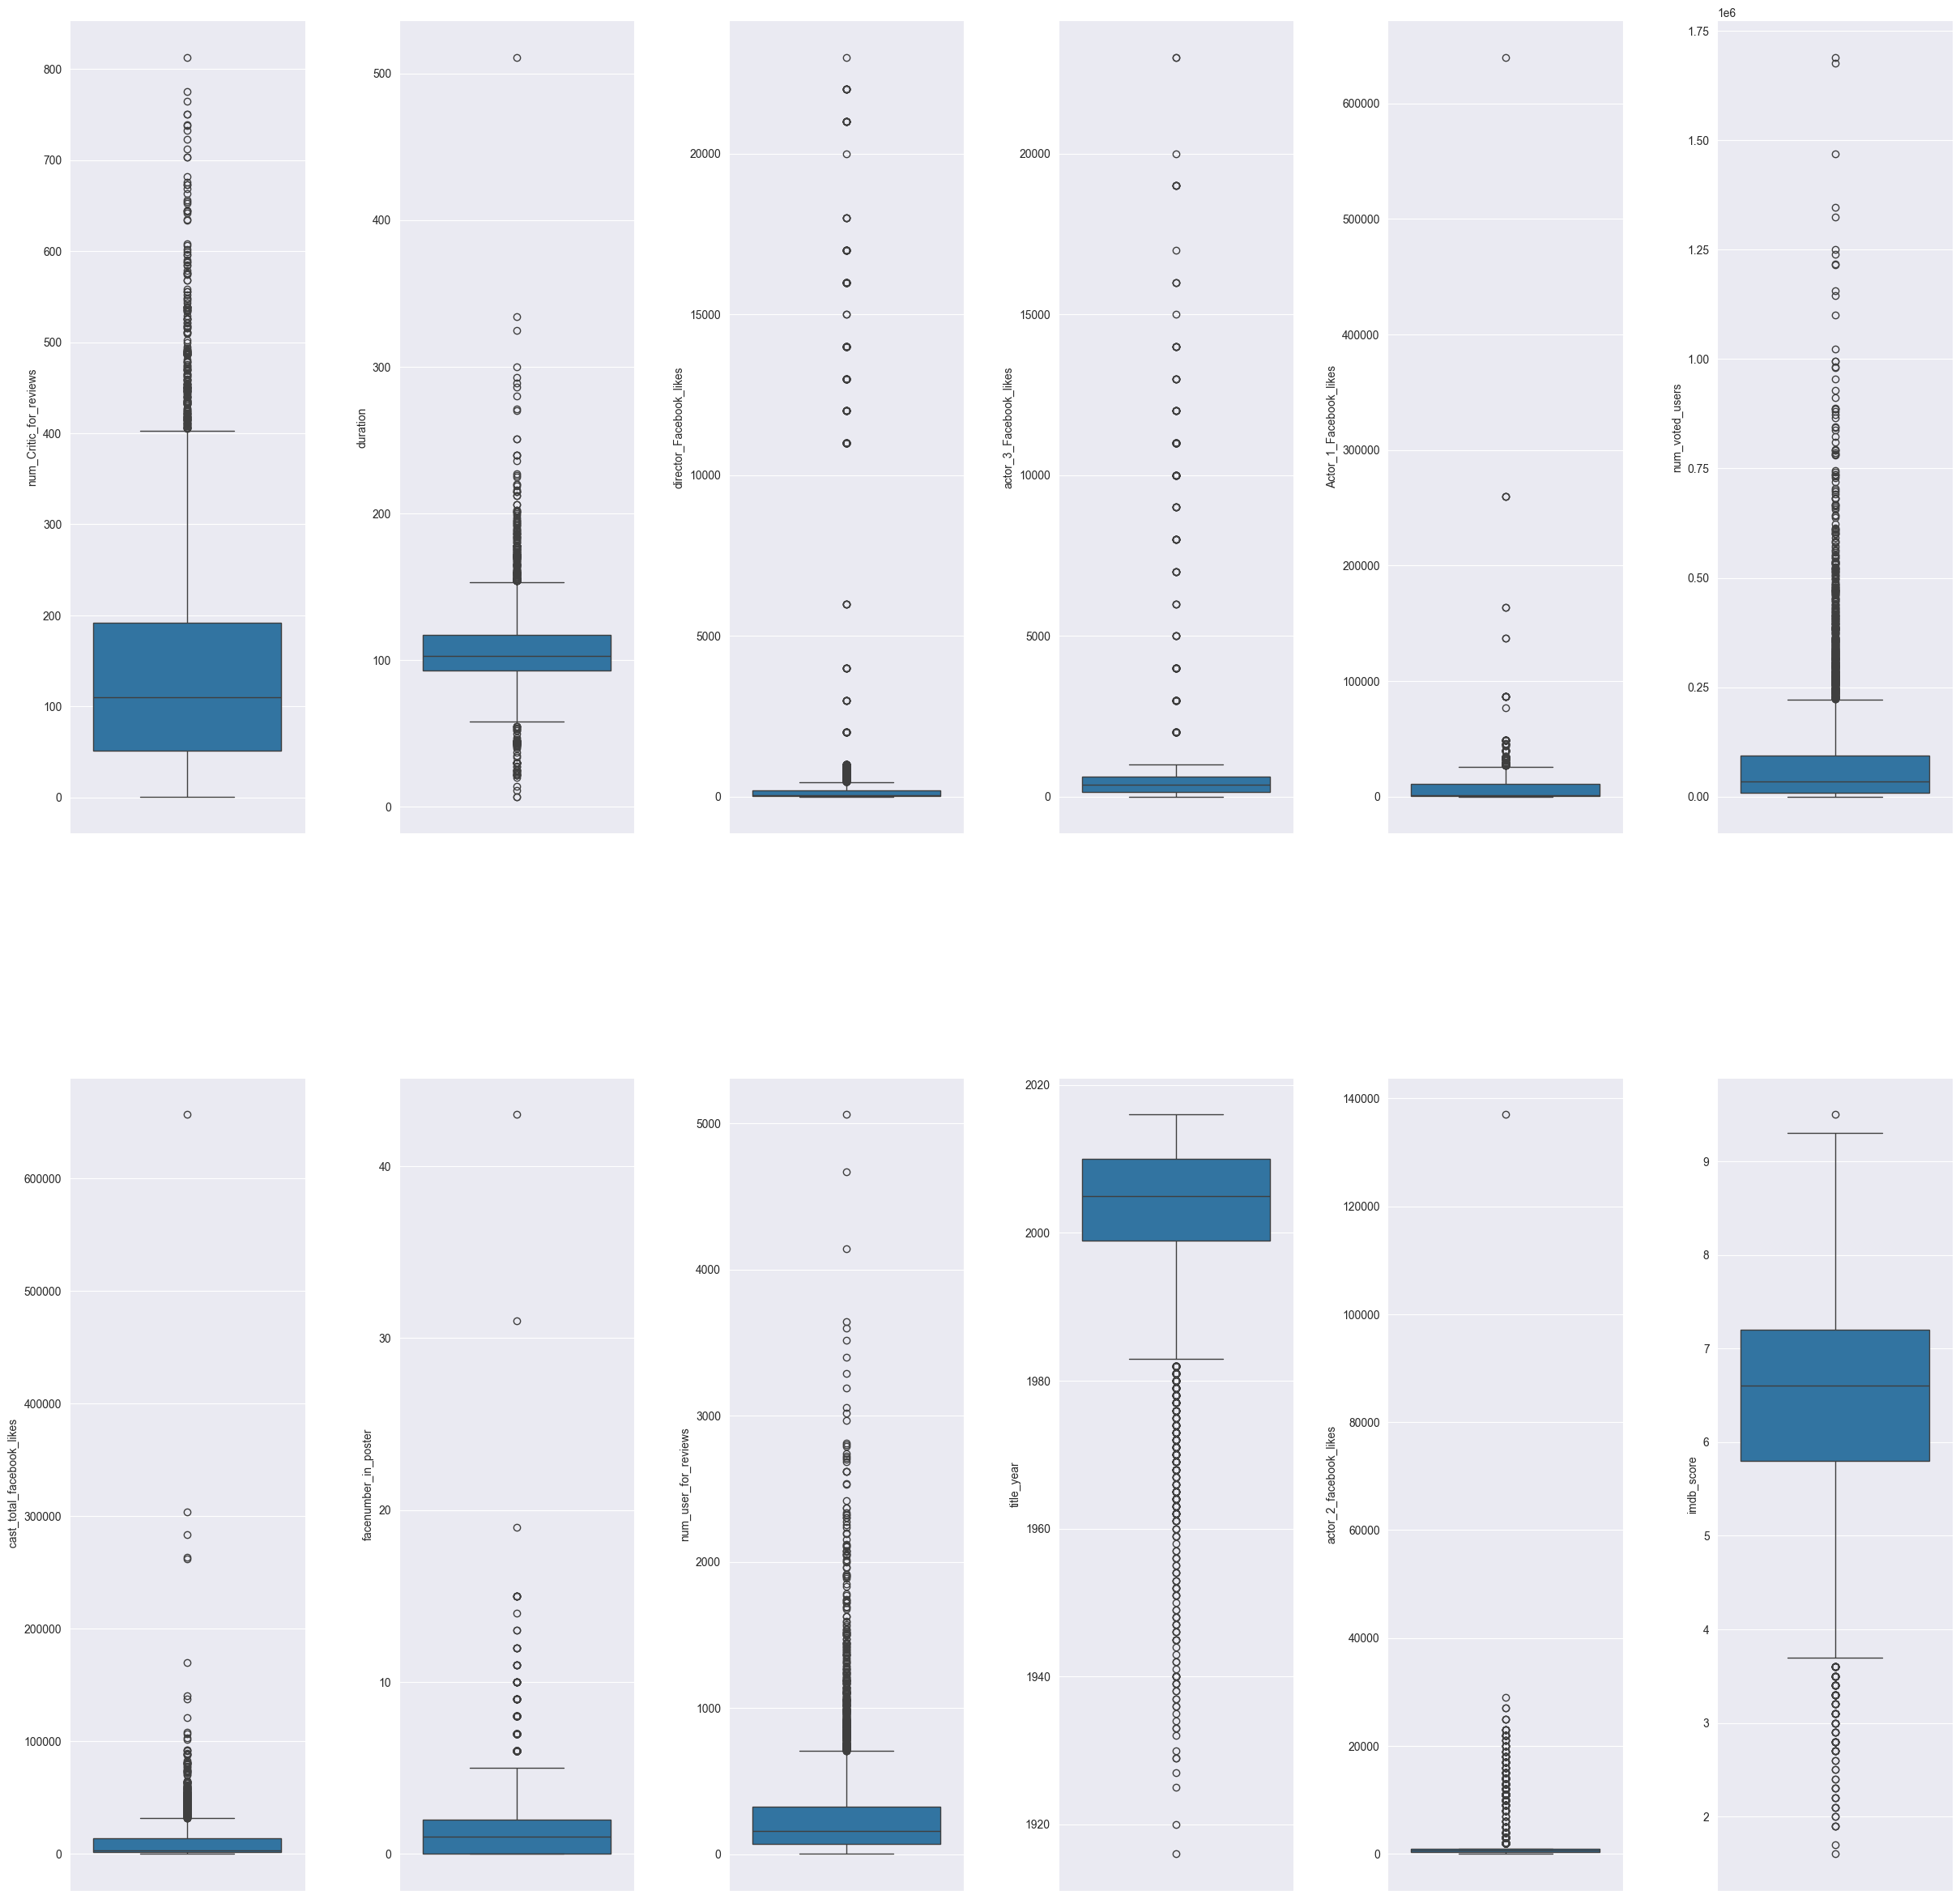

In [261]:
fig, axs = plt.subplots(2, 6, figsize=(30, 30))
plt.subplots_adjust(wspace=0.4, hspace=0.3)
ax_flatten = axs.flatten()
numeric_columns = movies_data.select_dtypes(include="number").columns
for i in range(len(ax_flatten)):
    sns.boxplot(movies_data, y = movies_data[numeric_columns[i]], ax = ax_flatten[i])

In [262]:
numeric_data = movies_data[numeric_columns]

q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)

IQR = q3 - q1

data_filtered = numeric_data[~((numeric_data < (q1 - 1.5 * IQR)) |(numeric_data > (q3 + 1.5 * IQR))).any(axis=1)]
data_filtered

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,real_domestic_gross,real_budget
4,110.0,103.0,131.0,372.0,131.0,8.0,143.0,0.0,157.0,2005.0,12.0,7.1,2.35,0.0,3.144961e+07,2.457829e+07
64,110.0,103.0,49.0,372.0,989.0,34504.0,3097.5,1.0,157.0,2005.0,595.0,6.6,2.35,165.5,3.144961e+07,2.457829e+07
98,1.0,120.0,28.0,12.0,544.0,374.0,699.0,0.0,13.0,2016.0,106.0,8.2,2.35,0.0,2.559138e+07,2.000000e+07
177,21.0,60.0,49.0,184.0,982.0,16769.0,1687.0,2.0,74.0,2005.0,321.0,7.5,1.33,0.0,3.144961e+07,1.843372e+06
199,1.0,103.0,0.0,159.0,10000.0,381.0,11036.0,1.0,2.0,2011.0,570.0,7.5,2.35,40.0,2.730567e+07,2.133974e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5037,14.0,95.0,0.0,133.0,296.0,1338.0,690.0,1.0,14.0,2011.0,205.0,6.4,2.35,413.0,4.891069e+03,9.602883e+03
5038,1.0,87.0,2.0,318.0,637.0,629.0,2283.0,2.0,6.0,2013.0,470.0,7.7,2.35,84.0,2.636585e+07,2.060526e+07
5040,13.0,76.0,0.0,0.0,0.0,38.0,0.0,0.0,3.0,2013.0,0.0,6.3,2.35,16.0,2.636585e+07,1.442368e+03
5041,14.0,100.0,0.0,489.0,946.0,1255.0,2386.0,5.0,9.0,2012.0,719.0,6.3,2.35,660.0,1.091663e+04,2.090708e+07


array([[<Axes: title={'center': 'num_Critic_for_reviews'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'director_Facebook_likes'}>,
        <Axes: title={'center': 'actor_3_Facebook_likes'}>],
       [<Axes: title={'center': 'Actor_1_Facebook_likes'}>,
        <Axes: title={'center': 'num_voted_users'}>,
        <Axes: title={'center': ' cast_total_facebook_likes'}>,
        <Axes: title={'center': 'facenumber_in_poster'}>],
       [<Axes: title={'center': 'num_user_for_reviews'}>,
        <Axes: title={'center': 'title_year'}>,
        <Axes: title={'center': 'actor_2_facebook_likes'}>,
        <Axes: title={'center': 'imdb_score'}>],
       [<Axes: title={'center': 'aspect_ratio'}>,
        <Axes: title={'center': 'movie_facebook_likes'}>,
        <Axes: title={'center': 'real_domestic_gross'}>,
        <Axes: title={'center': 'real_budget'}>]], dtype=object)

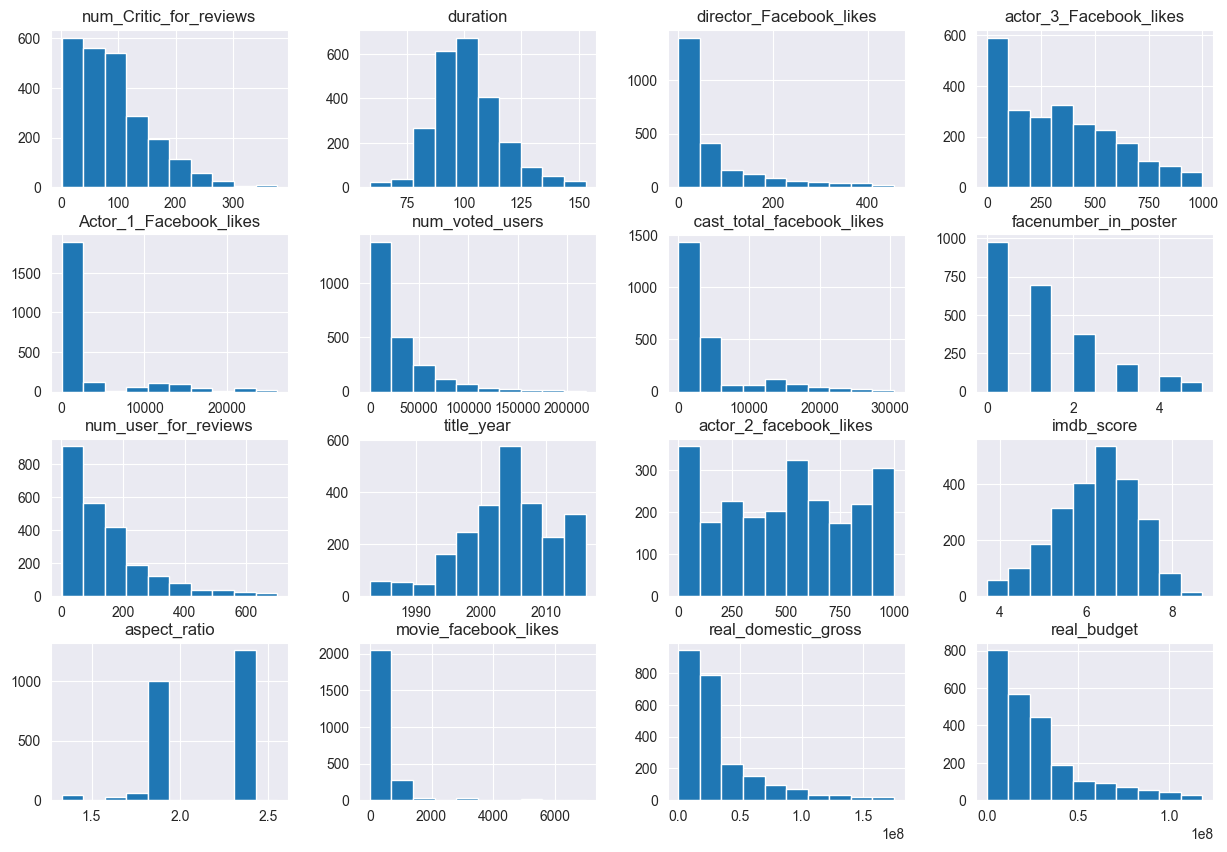

In [263]:
data_filtered.hist(figsize=(15, 10))

<Axes: >

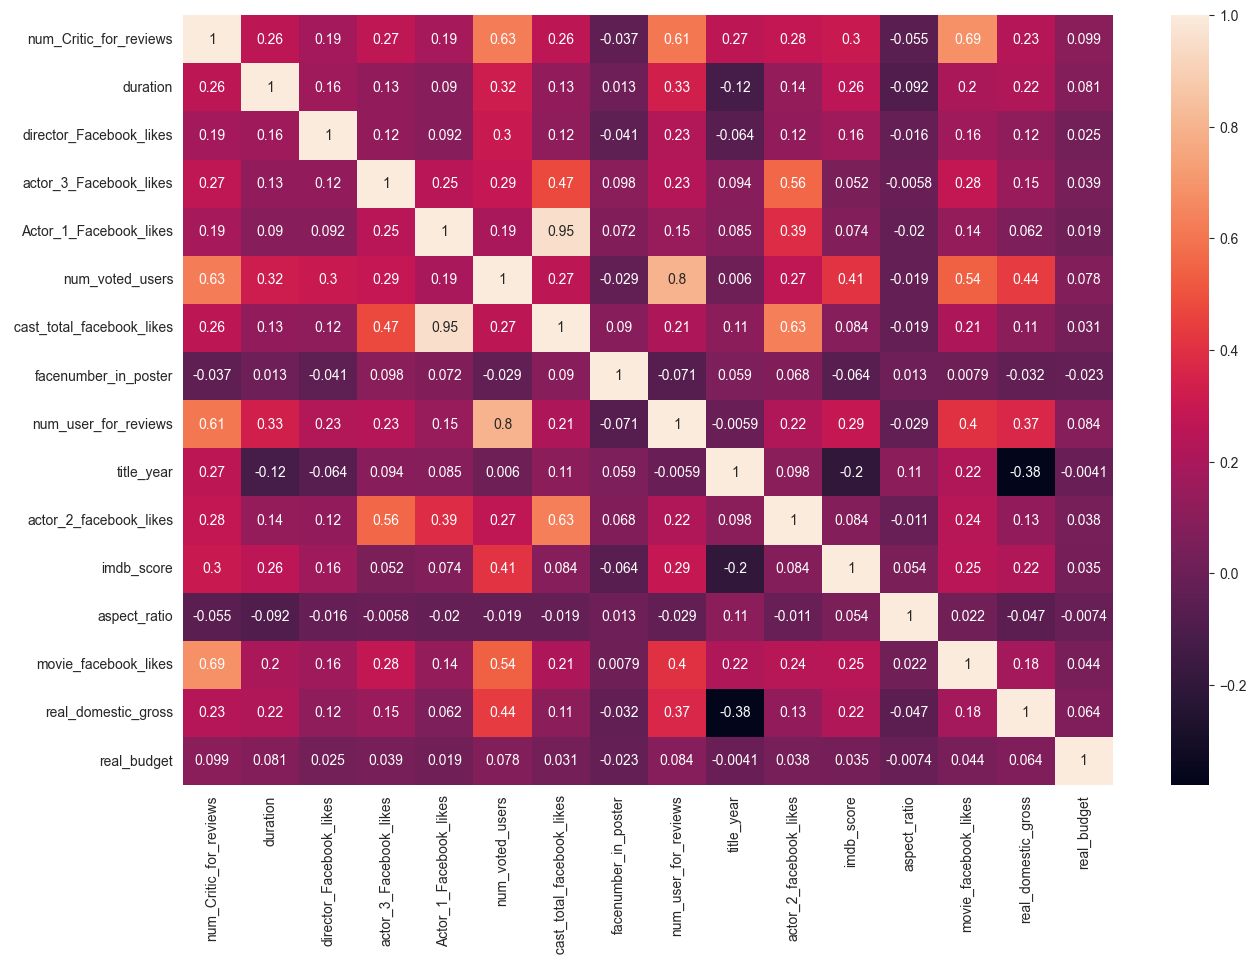

In [264]:
plt.figure(figsize=(15, 10))
sns.heatmap(movies_data[numeric_columns].corr(), annot=True)

<Axes: xlabel='title_year', ylabel='imdb_score'>

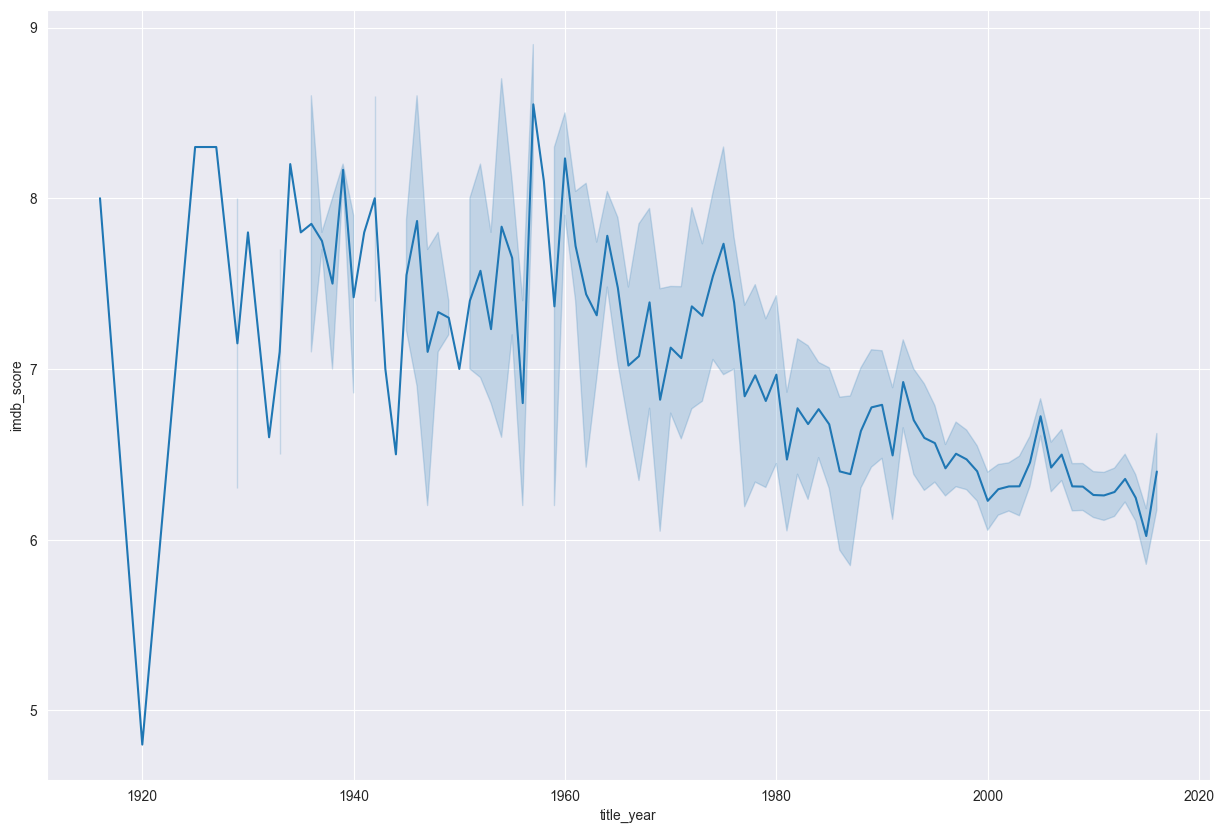

In [265]:
plt.figure(figsize=(15, 10))
sns.lineplot(movies_data, y = movies_data["imdb_score"], x=movies_data["title_year"], dashes=False)

<Axes: xlabel='real_budget', ylabel='real_domestic_gross'>

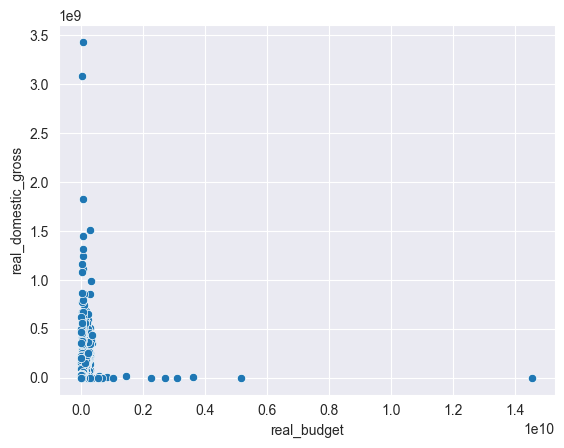

In [266]:
sns.scatterplot(movies_data, x=movies_data["real_budget"], y=movies_data["real_domestic_gross"])

([<matplotlib.patches.Wedge at 0x1f24c855190>,
 [Text(0.7590643462129464, 0.7961289583404892, 'Comedy'),
  Text(-0.7580720123009943, 0.7970739138661617, 'Action'),
  Text(-0.9402324847500187, -0.5709315848863207, 'Drama'),
  Text(-0.11389034742770514, -1.0940881997182845, 'Adventure'),
  Text(0.4191311407853244, -1.0170197081787515, 'Crime'),
  Text(0.7590648175833131, -0.796128508914994, 'Biography'),
  Text(0.9589032645331609, -0.5389847208109402, 'Horror'),
  Text(1.044304725329312, -0.3455830445129941, 'Documentary'),
  Text(1.0704372088513392, -0.2533064979556483, 'Animation'),
  Text(1.085713095462374, -0.17671183984529823, 'Fantasy'),
  Text(1.0936180741585728, -0.1183195160305126, 'Mystery'),
  Text(1.0970293694840068, -0.08078714309543968, 'Thriller'),
  Text(1.0985299160246849, -0.05685088916454059, 'Sci-Fi'),
  Text(1.0992570757608877, -0.04042129871270834, 'Western'),
  Text(1.0996918038528114, -0.02603721450058824, 'Family'),
  Text(1.0998966955659486, -0.01507511469630937

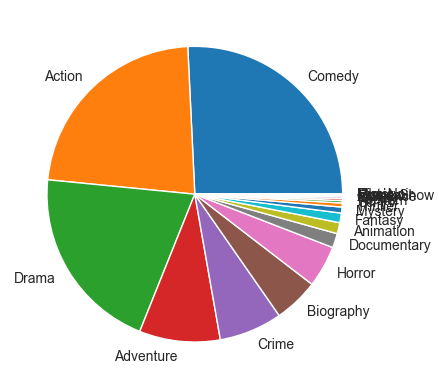

In [273]:
movies_data["main_genre"] = movies_data["genres"].str.split('|').str[0]
genres_count = movies_data["main_genre"].value_counts()
plt.pie(genres_count, labels=genres_count.index)